# Interpretability Notebook


This notebook provides a basic interpretability audit for the final tuned Random Forest model.

The goal is not to re-select or re-tune the model. Instead, this notebook explains the final model from two practical angles:

1. **Global feature importance:** identify which variables the Random Forest uses most for salary prediction, if feature names are available.
2. **Player-level residual analysis:** identify players whose observed 2025 salary differs most from the model-predicted salary.

All overpaid or underpaid labels in this notebook are **relative to the model-predicted salary**, not definitive claims about whether a player is truly underpaid or overpaid.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

repo = Path.cwd()

# Walk upward until we find the project root
while not (repo / "data").exists() and repo != repo.parent:
    repo = repo.parent

result_dir = repo / "results" / "Fixed"
art_dir = repo / "artifacts" / "Fixed"
audit_dir = result_dir / "audit fixed" 

print("Project root:", repo)
print("Results directory:", result_dir)
print("Artifacts directory:", art_dir)
print("Audit output directory:", audit_dir)


Project root: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation
Results directory: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed
Artifacts directory: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\artifacts\Fixed
Audit output directory: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed\audit fixed


## 1. Load final model and prediction output

The final tuned model is loaded from `artifacts/best_model.joblib`.

The player-level 2025 prediction output is loaded from `results/tuned_predictions.csv`.


In [4]:
model_path = art_dir / "best_model_fixed.joblib"
model = joblib.load(model_path)

print("Loaded model type:", type(model))
model


Loaded model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

 The cell below loads the saved 2025 prediction output and recomputes residuals using the same definition as `model_testing_fixed.ipynb`. This makes the interpretability notebook self-contained and ensures that the later residual analysis uses a consistent direction.

In [5]:
pred_path = result_dir / "tuned_predictions_fixed.csv"
pred_df = pd.read_csv(pred_path).copy()

required_cols = {"player", "team", "group", "actual", "predicted"}
missing_cols = required_cols - set(pred_df.columns)

if missing_cols:
    raise ValueError(f"Missing required columns in tuned_predictions.csv: {missing_cols}")

# Match the residual definition used in model_testing.ipynb:
# residual = predicted - actual
pred_df["residual"] = pred_df["predicted"] - pred_df["actual"]
pred_df["abs_error"] = pred_df["residual"].abs()

pred_df[[
    "player",
    "team",
    "group",
    "actual",
    "predicted",
    "residual",
    "abs_error"
]].head()


,player,team,group,actual,predicted,residual,abs_error
0,A'ja Wilson,LVA,veteran,200000,227019.917506,27019.917506,27019.917506
1,Aaliyah Edwards,TOT,rookie,74909,69542.147209,-5366.852791,5366.852791
2,Aaliyah Nye,LVA,rookie,69267,73160.608659,3893.608659,3893.608659
3,Aari McDonald,IND,veteran,52333,129520.193440,77187.193440,77187.193440
4,Aerial Powers,TOT,veteran,11924,75257.874048,63333.874048,63333.874048


## 2. Global Feature Importance

For the final Gradient Boosting Regressor model, built-in feature importance is a simple global interpretability diagnostic. It shows which features the model used most when making predictions.

This is a model diagnostic, not a causal interpretation. A high feature-importance score does not mean that the feature causes salary to increase or decrease. It only means that the feature was useful to the model's prediction process.

In [6]:
# Try to recover feature names from the fitted model.
# If feature names were not saved in the model object, this section reports that limitation instead of failing.

feature_names = None

if hasattr(model, "feature_names_in_"):
    feature_names = list(model.feature_names_in_)
    print(f"Recovered {len(feature_names)} feature names from model.feature_names_in_.")
else:
    print("The model does not store feature_names_in_. Feature names may need to be recovered from the training notebook.")

if feature_names is not None:
    feature_names[:10]


Recovered 26 feature names from model.feature_names_in_.


In [7]:
# Create feature-importance table if possible.

importance_df = None

if hasattr(model, "feature_importances_") and feature_names is not None:
    if len(feature_names) != len(model.feature_importances_):
        print("Feature name count does not match feature_importances_ length.")
        print("Feature importance table will not be created automatically.")
    else:
        importance_df = (
            pd.DataFrame({
                "feature": feature_names,
                "importance": model.feature_importances_
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        display(importance_df.head(20))
else:
    print("Feature importance table cannot be created automatically.")
    print("Reason: either the model does not expose feature_importances_, or feature names are unavailable.")


,feature,importance
0,start_rate,0.484541
1,pts_vet,0.152606
2,fg_per_g,0.084321
3,avail_rate,0.037598
4,pts_rookie,0.035134
5,fga,0.028864
6,mp,0.026471
7,tov,0.022600
8,g,0.020991
9,group_rookie,0.020606


### Feature-importance interpretation

The feature-importance table shows that `start_rate` is the most important feature in the final Gradient Boosting Regressor model. Its importance score is much larger than the others, suggesting that the model relies heavily on starting-role information when predicting salary.

Other important features include `pts_vet`, `fg_per_g`, `avail_rate`, `pts_rookie`, `fga`, `mp`, `tov`, `g`, and `group_rookie`. These features mainly capture scoring production, playing time, availability, and contract/player group status.

## 3. Player-level prediction error interpretation

Player-level prediction error analysis was already performed in the section 5 of `model_comparison fixed.ipynb`, where the notebook inspected:

1. **largest absolute errors** show the largest prediction mistakes;
2. **largest positive residuals** show players whose predicted salary is much higher than their actual salary, so they appear underpaid relative to the model predicted salary;
3. **smallest residuals** show players whose predicted salary is much lower than their actual salary, so they appear overpaid relative to the model predicted salary.


## 4. Feature-importance plot

This plot visualizes the top 15 feature importances from the final Random Forest model.


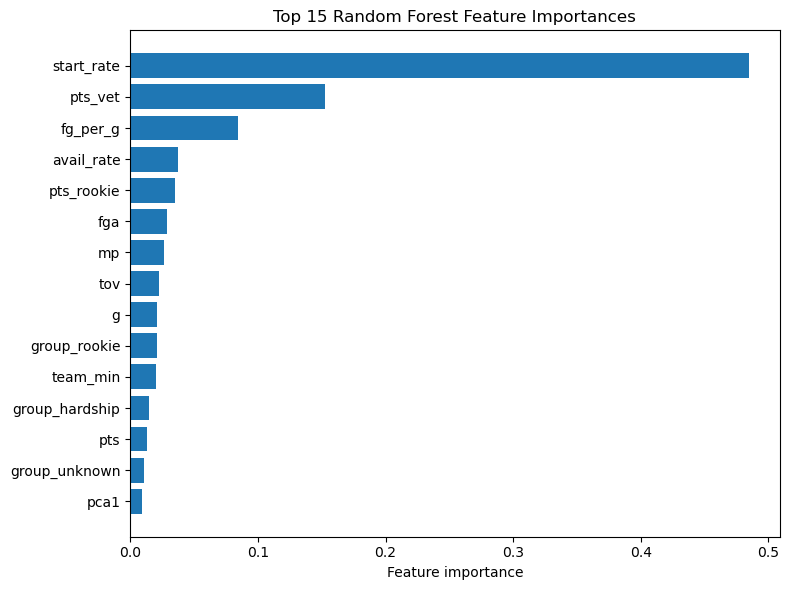

In [8]:
import matplotlib.pyplot as plt

if importance_df is not None:
    top_features = importance_df.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_features["feature"], top_features["importance"])
    ax.set_xlabel("Feature importance")
    ax.set_title("Top 15 Random Forest Feature Importances")
    fig.tight_layout()

    plt.show()
else:
    print("Feature-importance plot skipped because importance_df was not created.")


## 5. Save interpretability audit outputs

This section saves the main interpretability tables to `results/audit/`.


In [9]:
# Save interpretability audit outputs to results/audit/.

audit_dir.mkdir(parents=True, exist_ok=True)

if importance_df is not None:
    importance_path = audit_dir / "feature_importance_audit_fixed.csv"
    importance_df.to_csv(importance_path, index=False)
    print(f"Saved feature importance table to: {importance_path}")

if "fig" in globals():
    plot_path = audit_dir / "feature_importance_plot_fixed.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"Saved feature importance plot to: {plot_path}")
else:
    print("Feature importance plot was not saved because no figure object was found.")

Saved feature importance table to: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed\audit fixed\feature_importance_audit_fixed.csv
Saved feature importance plot to: c:\Users\lelin\Documents\GitHub\summer26-wnba-player-valuation\results\Fixed\audit fixed\feature_importance_plot_fixed.png


## 6. Interpretability conclusion

Key conclusions:

* This notebook focuses on the final tuned Gradient Boosting model.
* The main interpretability output is the feature-importance analysis.
* `start_rate` is the dominant feature used by the model for salary prediction.
* Other important features are mostly related to scoring, playing time, availability, and player group status.
* Feature importance should be interpreted as a model diagnostic, not as a causal explanation.
* Player-level prediction error interpretation is handled separately in the section 5 of `model_comparison fixed.ipynb`.
* The feature-importance table and plot are saved in `results/Fixed/audit fixed` for reporting and review.

